# DepMap Mutation 기반 유전체 불안정성(WGD/CIN/LOH) 예측 — 전체 파이프라인

DepMap Public 26Q1 / 1,631개 세포주 / hotspot 554 + damaging 19,578 mutation feature 로
Whole Genome Doubling(WGD), Chromosomal Instability(CIN), Loss of Heterozygosity(LOH)를
예측하고, 최소 mutation biomarker panel을 찾는 프로젝트의 전체 파이프라인이다.

전체 코드/문서: https://github.com/lkeonwoo94/AI-bio-proj-team-1

**노트북 구성**
1. 데이터 로드 & 코호트 요약
2. EDA — mutation/표현형 분포
3. 5개 모델 비교 (Logistic/Elastic Net/Random Forest/XGBoost/CatBoost)
4. 최고 성능 모델(Random Forest) confusion matrix
5. 반복 feature selection — 어떤 mutation이 중요한가
6. 최소 mutation panel — 몇 개까지 줄여도 되는가
7. Lineage(암종) 일반화 — GroupKFold / Leave-One-Lineage-Out
8. CIN/LOH 이진화가 정보를 버리는가 — 회귀로 직접 검증
9. Pathway 단위 재집계 (실행 결과 — 음성)
10. Mutation signature(96-class) 표현 (실행 결과 — 양성)
11. 유전자 + Signature 결합 패널
12. Sensitivity/Specificity 트레이드오프
13. TCGA 외부 코호트 검증
14. 최종 후보 Biomarker Panel
15. 결론 및 한계

**중요**: 이 노트북은 무거운 nested cross-validation(모델 5개 × 표현형 3개 × outer
5-fold × inner 5-fold, 실제로는 수십 분\~수 시간 소요)을 노트북 실행마다 새로
돌리지 않는다. 그 계산은 `scripts/`의 개별 스크립트가 이미 수행해 `results/tables/`,
`results/figures/`에 저장해 두었고(모두 git에 커밋됨), 이 노트북은 **그 결과를
불러와 재현·시각화**한다. 각 절에 재현용 스크립트 커맨드를 적어두었다 — 직접
처음부터 다시 돌리고 싶다면 그 커맨드를 실행하면 된다(모든 계산은 §13
원칙에 따라 outer test 데이터가 threshold/feature selection 어디에도 관여하지
않도록 leakage를 방지한다).

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

TABLES = REPO_ROOT / "results" / "tables"
FIGURES = REPO_ROOT / "results" / "figures"

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: /home/kali/adni-shared/AI-bio-proj-team-1


## 1. 데이터 로드 & 코호트 요약

DepMap 4개 원본 파일(hotspot/damaging mutation matrix, global signatures, model
metadata)을 ModelID 교집합으로 합치고 라벨 결측을 제거한다. 이 단계는 실제로
가볍게 실행된다(수 초).

In [2]:
from src.data.merge import load_cohort

cohort = load_cohort()
print(cohort.summary())
print()
print("X shape:", cohort.X.shape, "| dtype:", cohort.X.dtypes.iloc[0])
print("y columns:", list(cohort.y.columns))
print("lineage 수:", cohort.groups.nunique())
cohort.y.describe()

세포주 1,631 | feature 20,132 (hotspot 554 / damaging 19,578) | lineage 32종

X shape: (1631, 20132) | dtype: int8
y columns: ['wgd', 'cin', 'loh']
lineage 수: 32


,wgd,cin,loh
count,1631.000000,1631.000000,1631.000000
mean,0.652361,0.460105,0.210227
std,0.476367,0.246927,0.162156
min,0.000000,0.000000,0.000000
25%,0.000000,0.242061,0.073253
50%,1.000000,0.533116,0.187137
75%,1.000000,0.663973,0.318579
max,1.000000,0.859347,0.929901


데이터 원본 파일별 상세 통계는 `docs/depmap/input_data_summary.md`,
mutation matrix 병합 과정은 `docs/depmap/mutation_matrix.md`,
라벨(WGD/CIN/LoHFraction) 정의는 `docs/depmap/global_signatures.md` 참고.

## 2. EDA — mutation 빈도 / 표현형 분포

**Figure 2.** WGD/CIN/LOH 세 표현형의 분포. WGD는 이진(65.2%가 양성), CIN은
이봉형, LOH는 0 근처로 치우친 분포다.

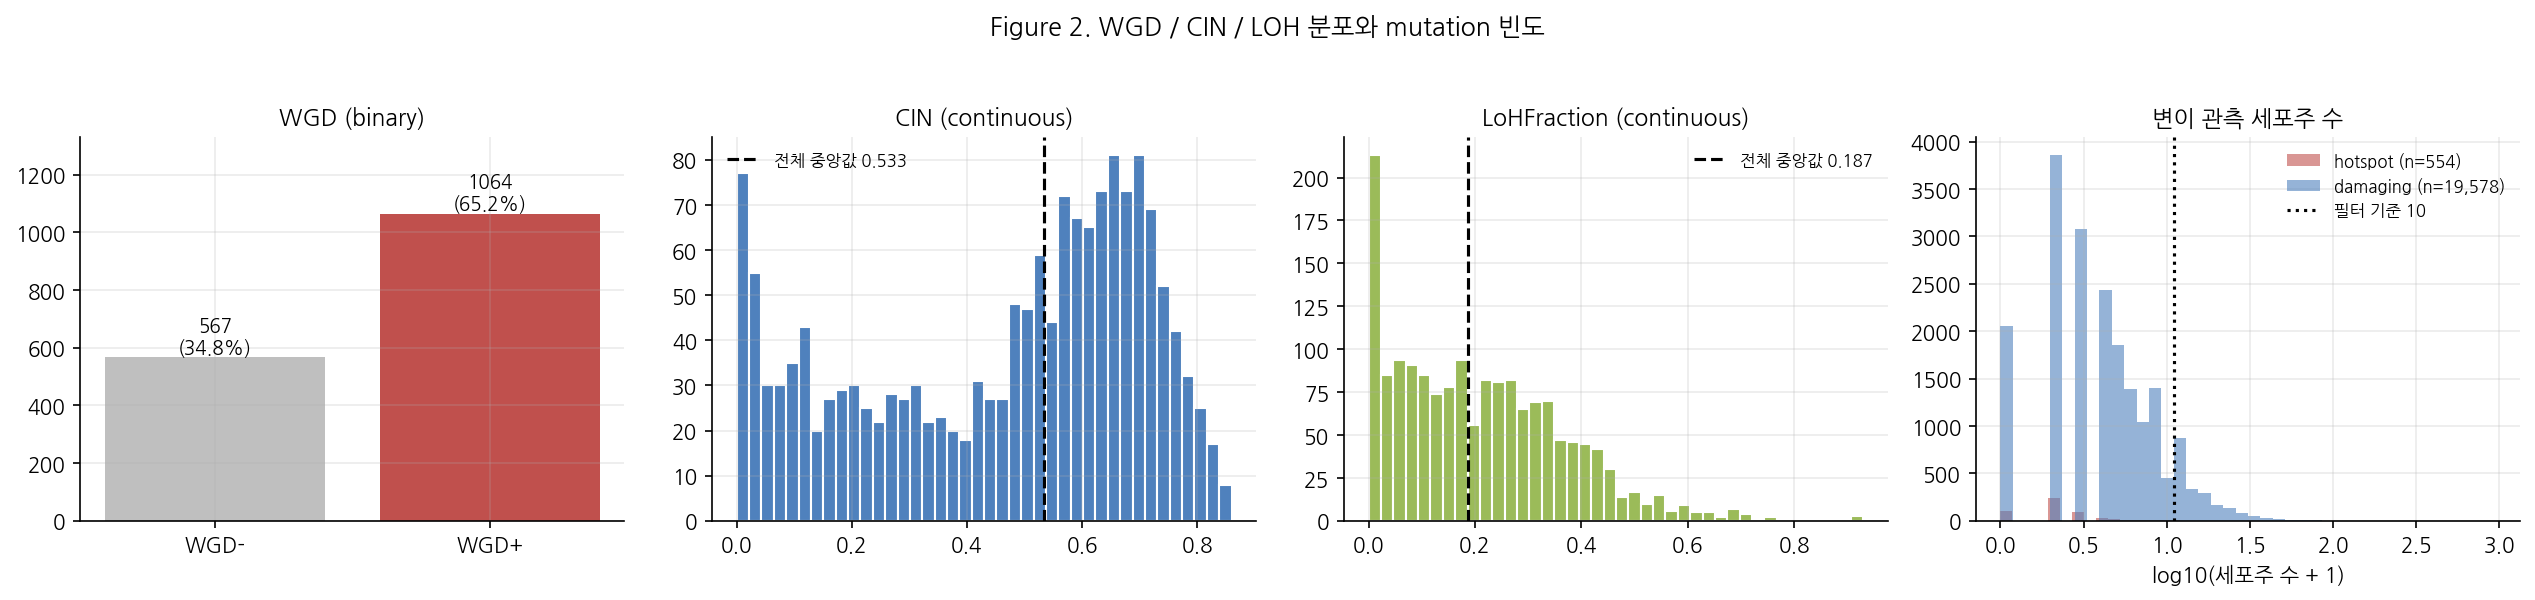

In [3]:
display(Image(filename=str(FIGURES / "fig2_phenotype_distribution.png")))

## 3. 모델 비교 — 5개 모델 × 3표현형

Logistic Regression, Elastic Net, Random Forest, XGBoost, CatBoost를 동일한
nested cross-validation(outer 5-fold × inner 5-fold) 조건에서 비교했다. 희귀
변이 제거, CIN/LOH 이진화 threshold, hyperparameter, 분류 threshold는 모두 각
training fold 내부에서만 결정된다(outer test 데이터는 관여하지 않음, README §13).

재현: `python scripts/05_run_cv.py --model {model} --target {target}`
(model × target 조합마다), 집계는 `python scripts/06_compare_models.py`.

In [4]:
day10 = pd.read_csv(TABLES / "day10_model_comparison.csv")
day10_pivot = day10.pivot(index="model", columns="target", values="roc_auc")
day10_pivot = day10_pivot[["wgd", "cin", "loh"]].sort_values("wgd", ascending=False)
print("모델별 ROC-AUC (random 5-fold)")
day10_pivot.round(3)

모델별 ROC-AUC (random 5-fold)


target,wgd,cin,loh
model,,,
random_forest,0.765,0.734,0.730
catboost,0.762,0.711,0.717
xgboost,0.757,0.729,0.728
elastic_net,0.749,0.681,0.711
logistic,0.723,0.672,0.683
multitask_ann,0.704,0.671,0.667


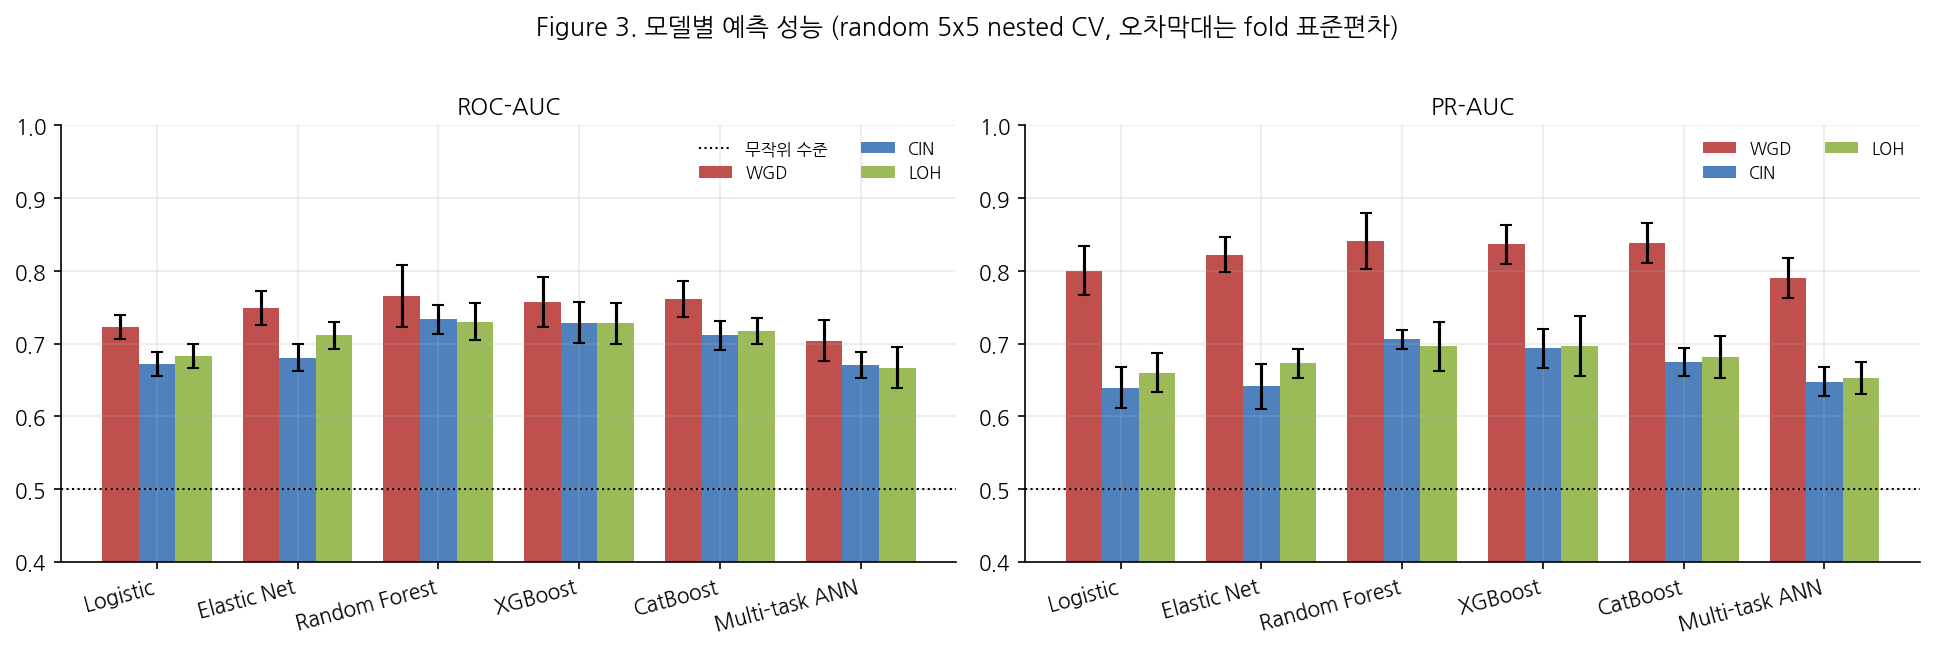

In [5]:
display(Image(filename=str(FIGURES / "fig3_model_comparison.png")))

**Random Forest가 세 표현형 모두에서 1위**다(WGD 0.765 / CIN 0.734 / LOH 0.730).
비선형 모델(RF/XGBoost/CatBoost, 평균 0.73\~0.74)이 선형 모델(평균 0.69\~0.71)을
일관되게 앞서지만 그 차이는 0.05 내외다.

## 4. Random Forest confusion matrix (최고 성능 모델)

5개 outer fold의 test 예측을 모두 모아(pooled) 하나의 confusion matrix로
합쳤다. Threshold는 각 fold의 training 데이터 안에서 out-of-fold 예측으로만
결정했다(§13).

재현: `python scripts/33_rf_confusion_matrix.py`, `python scripts/34_plot_rf_confusion_matrix.py`.

In [6]:
cm = pd.read_csv(TABLES / "day33_rf_confusion_matrix.csv")
cm

,target,tn,fp,fn,tp,n,sensitivity,specificity,balanced_accuracy
0,wgd,384,183,264,800,1631,0.751880,0.677249,0.714564
1,cin,538,277,248,568,1631,0.696078,0.660123,0.678101
2,loh,494,321,207,609,1631,0.746324,0.606135,0.676229


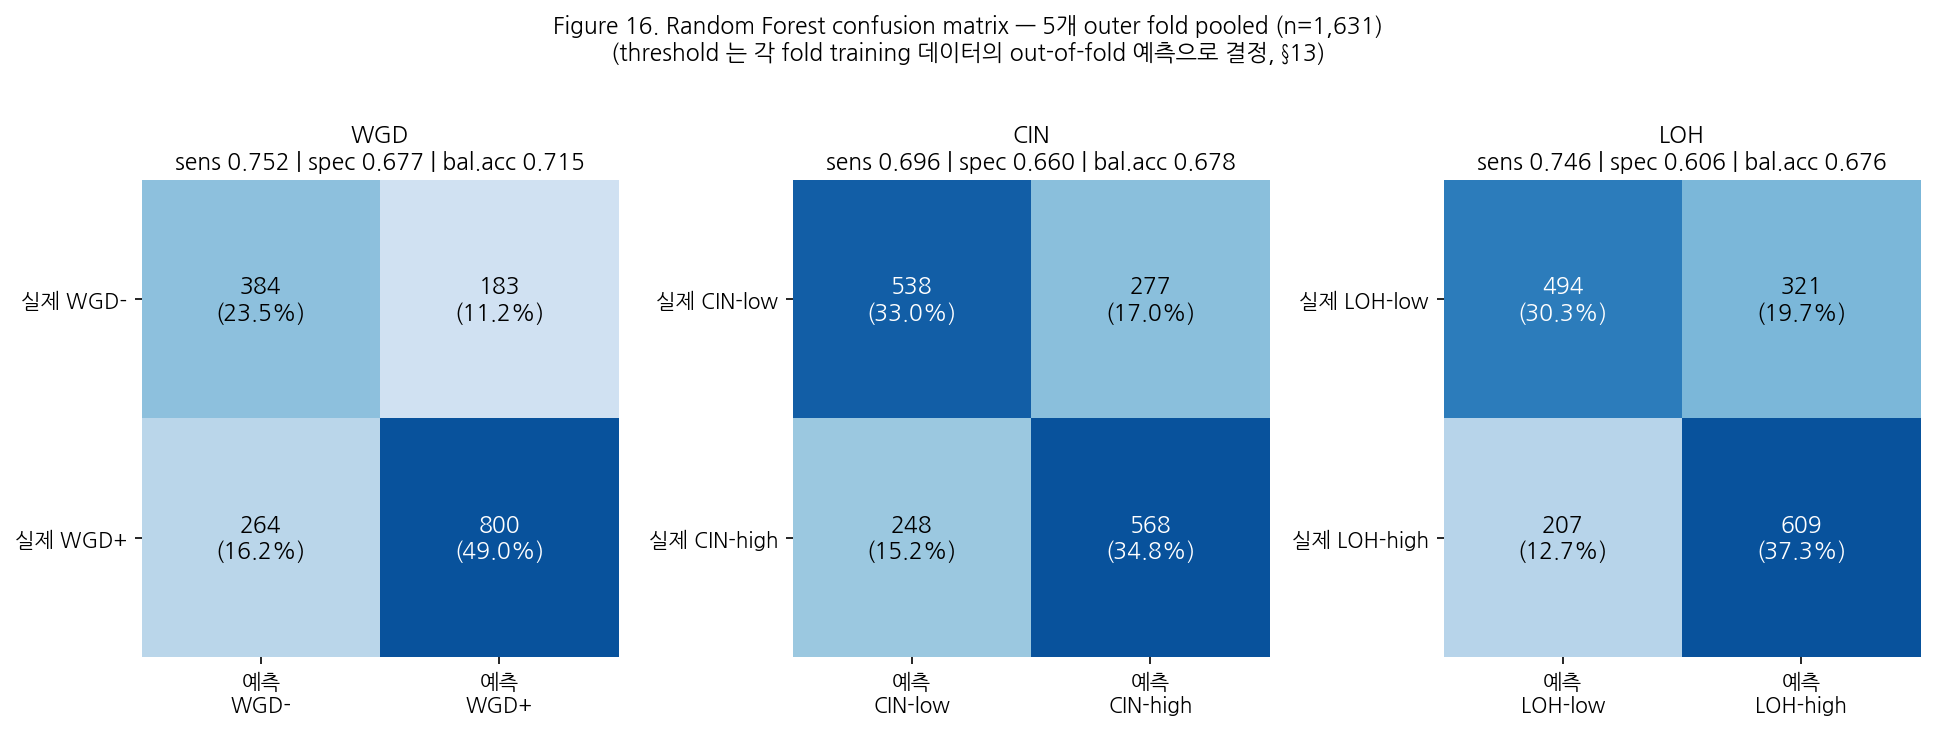

In [7]:
display(Image(filename=str(FIGURES / "fig16_rf_confusion_matrix.png")))

## 5. 반복 Feature Selection — 어떤 mutation이 중요한가

각 outer fold의 training data에서 feature selection을 반복해, 5개 fold 모두에서
선택된("전 fold 공통") 유전자를 찾는다. Elastic Net과 Random Forest 두 모델
기준으로 각각 뽑았다.

재현: `python scripts/07_aggregate_selection.py --model {elastic_net,random_forest}`.

In [8]:
for model in ("elastic_net", "random_forest"):
    print(f"=== {model} ===")
    for target in ("wgd", "cin", "loh"):
        df = pd.read_csv(TABLES / f"day11_selection_{model}_{target}.csv")
        common = df[df.selection_freq == 1.0]
        genes = ", ".join(common.gene.head(8))
        print(f"  {target.upper()}: 전 fold(5/5) 공통 {len(common)}개 — {genes}")
    print()

=== elastic_net ===
  WGD: 전 fold(5/5) 공통 12개 — TP53, BRAF, ID3, TERT, TP53, CREBBP, LRP1B, CCND3
  CIN: 전 fold(5/5) 공통 5개 — TP53, ID3, BRAF, TERT, RB1
  LOH: 전 fold(5/5) 공통 9개 — TP53, NF2, ID3, PITX1, RB1, BRAF, CREBBP, MUC19

=== random_forest ===
  WGD: 전 fold(5/5) 공통 19개 — TP53, TP53, TERT, BRAF, ID3, LRP1B, TTN, KRAS
  CIN: 전 fold(5/5) 공통 21개 — TP53, TP53, TERT, RB1, ID3, BRAF, PIK3CA, KRAS
  LOH: 전 fold(5/5) 공통 18개 — TP53, TP53, RB1, ID3, KRAS, NF2, ARID1A, PITX1



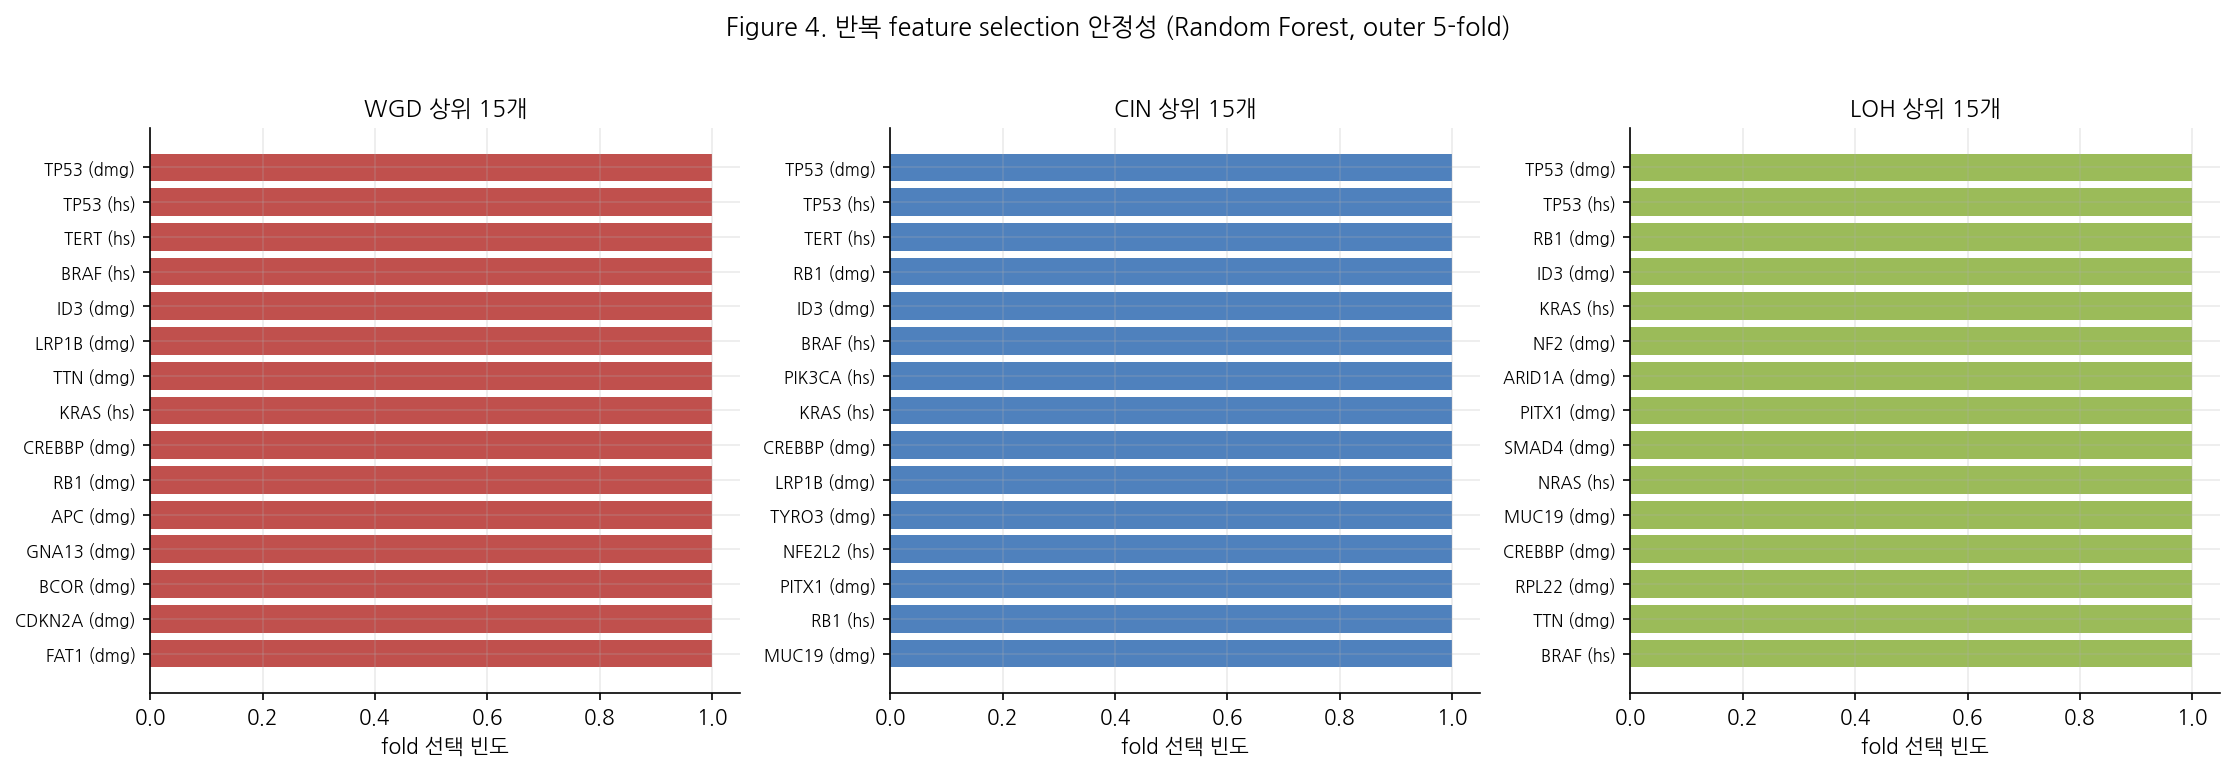

In [9]:
display(Image(filename=str(FIGURES / "fig4_selection_stability_random_forest.png")))

## 6. 최소 mutation panel — 몇 개까지 줄여도 되는가

5/10/20/50개로 축소한 패널이 전체 feature 대비 성능을 얼마나 유지하는지,
그리고 fold 간 패널 구성의 안정성(Jaccard 유사도)을 본다.

재현: `python scripts/08_panel_curve.py --model {elastic_net,random_forest}`.

In [10]:
panel = pd.read_csv(TABLES / "day12_panel_metrics_random_forest.csv")
panel_pivot = panel.pivot_table(index="target", columns="panel_size", values="roc_auc", aggfunc="mean")
panel_pivot = panel_pivot.reindex(columns=["5", "10", "20", "50", "all"])
print("Random Forest — 패널 크기별 ROC-AUC")
panel_pivot.round(3)

Random Forest — 패널 크기별 ROC-AUC


panel_size,5,10,20,50,all
target,,,,,
cin,0.671,0.682,0.699,0.718,0.734
loh,0.666,0.687,0.709,0.715,0.730
wgd,0.723,0.729,0.740,0.751,0.765


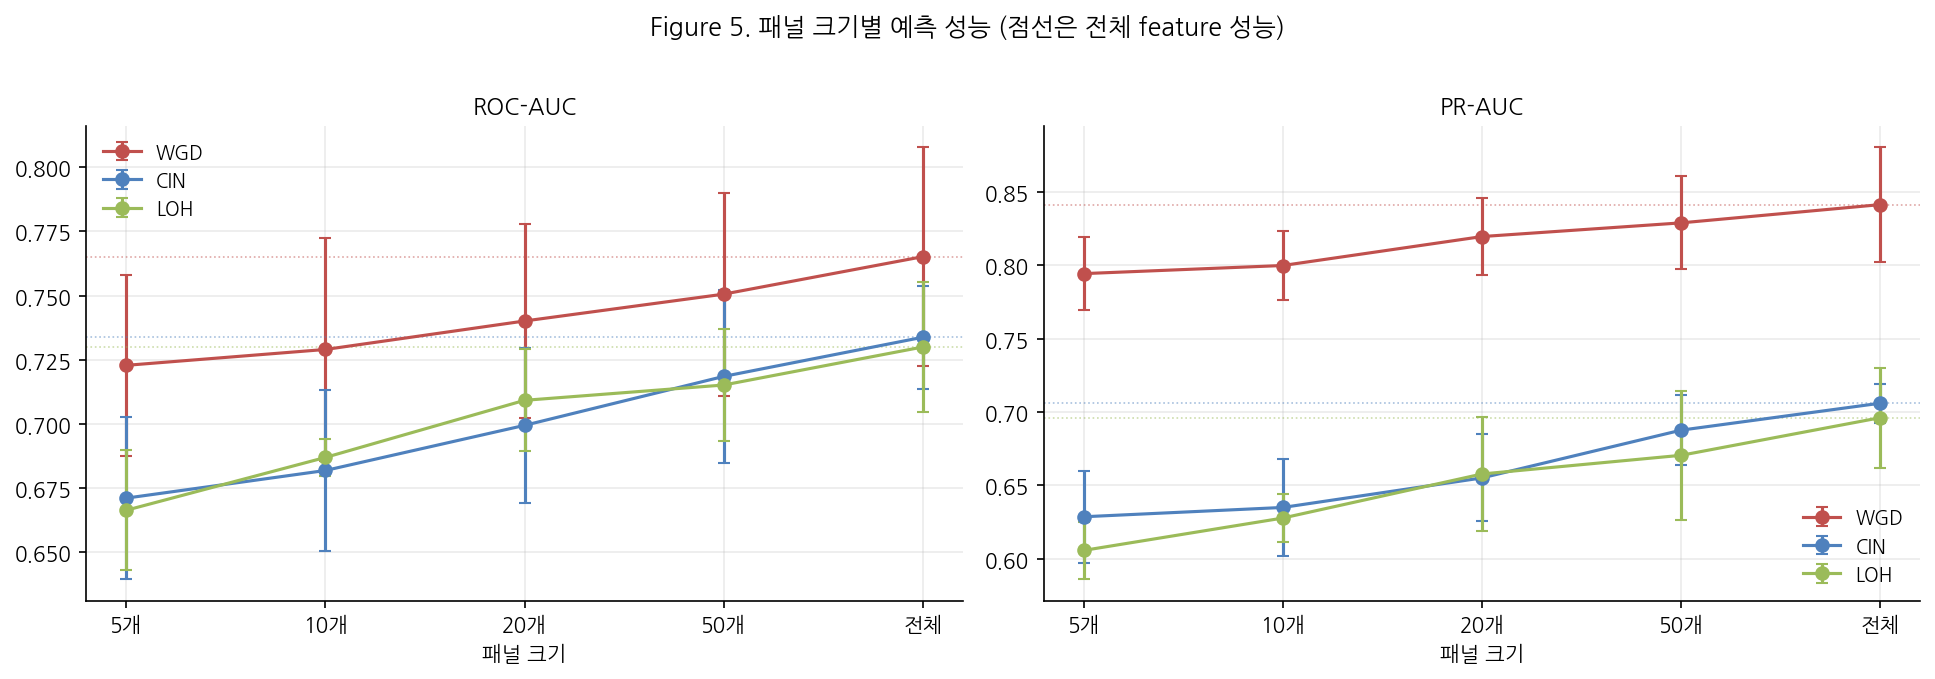

In [11]:
display(Image(filename=str(FIGURES / "fig5_panel_curve_random_forest.png")))

**10개 패널로 전체 성능의 93\~99%가 유지된다.** 다만 fold마다 어떤 유전자가
뽑히는지는 달라진다(Jaccard 유사도 <1) — `day12_panel_stability_random_forest.csv`
참고. 자세한 해석은 `docs/research/2026-08-16/final_conclusion.md` §26④,
"Day 11/12 Random Forest 재검증" 절 참고.

## 7. Lineage(암종) 일반화 — GroupKFold / Leave-One-Lineage-Out

같은 lineage(암종)의 세포주가 train/test에 섞이지 않도록 분리하면 성능이
어떻게 달라지는지 본다.

재현: `python scripts/09_lineage_validation.py --model {elastic_net,random_forest}`,
`python scripts/11_lineage_specific.py`,
`python scripts/15_lineage_hypothesis_test.py`.

In [12]:
lineage_cmp = pd.read_csv(TABLES / "day13_lineage_comparison_random_forest.csv")
lineage_cmp

,target,group,random,차이
0,cin,0.677864,0.733763,-0.055899
1,loh,0.683452,0.729966,-0.046514
2,wgd,0.700460,0.765161,-0.064701


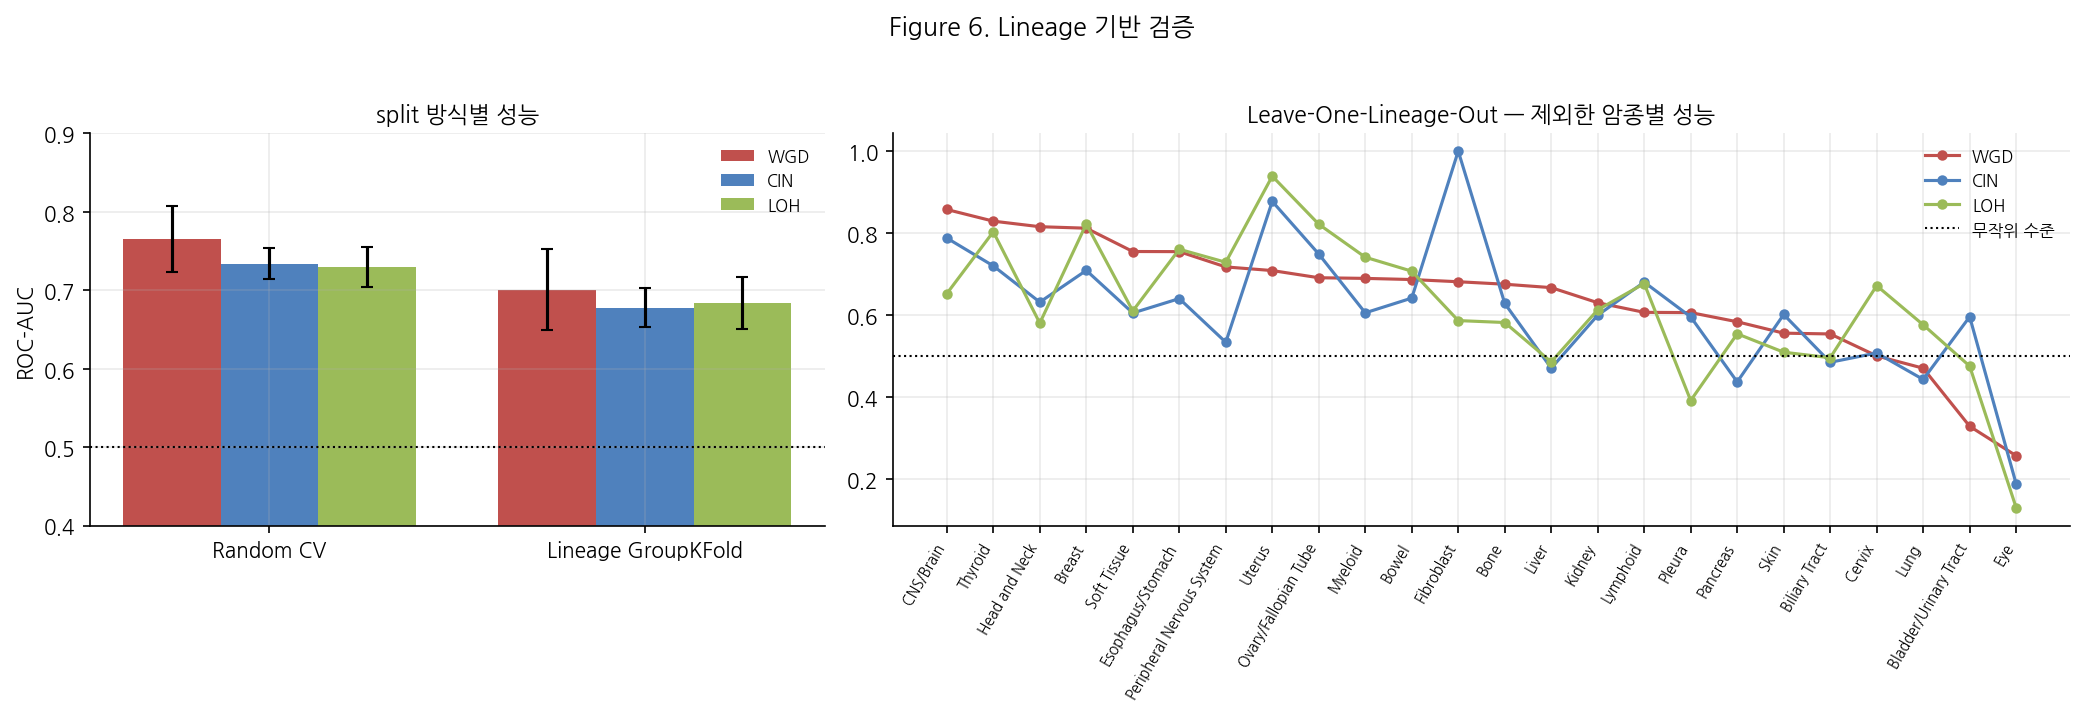

In [13]:
display(Image(filename=str(FIGURES / "fig6_lineage_validation_random_forest.png")))

Leave-One-Lineage-Out(LOLO)에서는 암종별 성능 편차가 훨씬 크다(WGD 기준
0.314\~0.882). 왜 어떤 암종에서는 신호가 있고 어떤 암종에서는 없는지 다섯 개
가설(기저율, 표본 크기, TP53 변이율, mutation burden, TP53 변이율의 극단성)로
검정했으나 모두 기각됐다 — 단순 단변량 교란변수로는 설명되지 않는다.

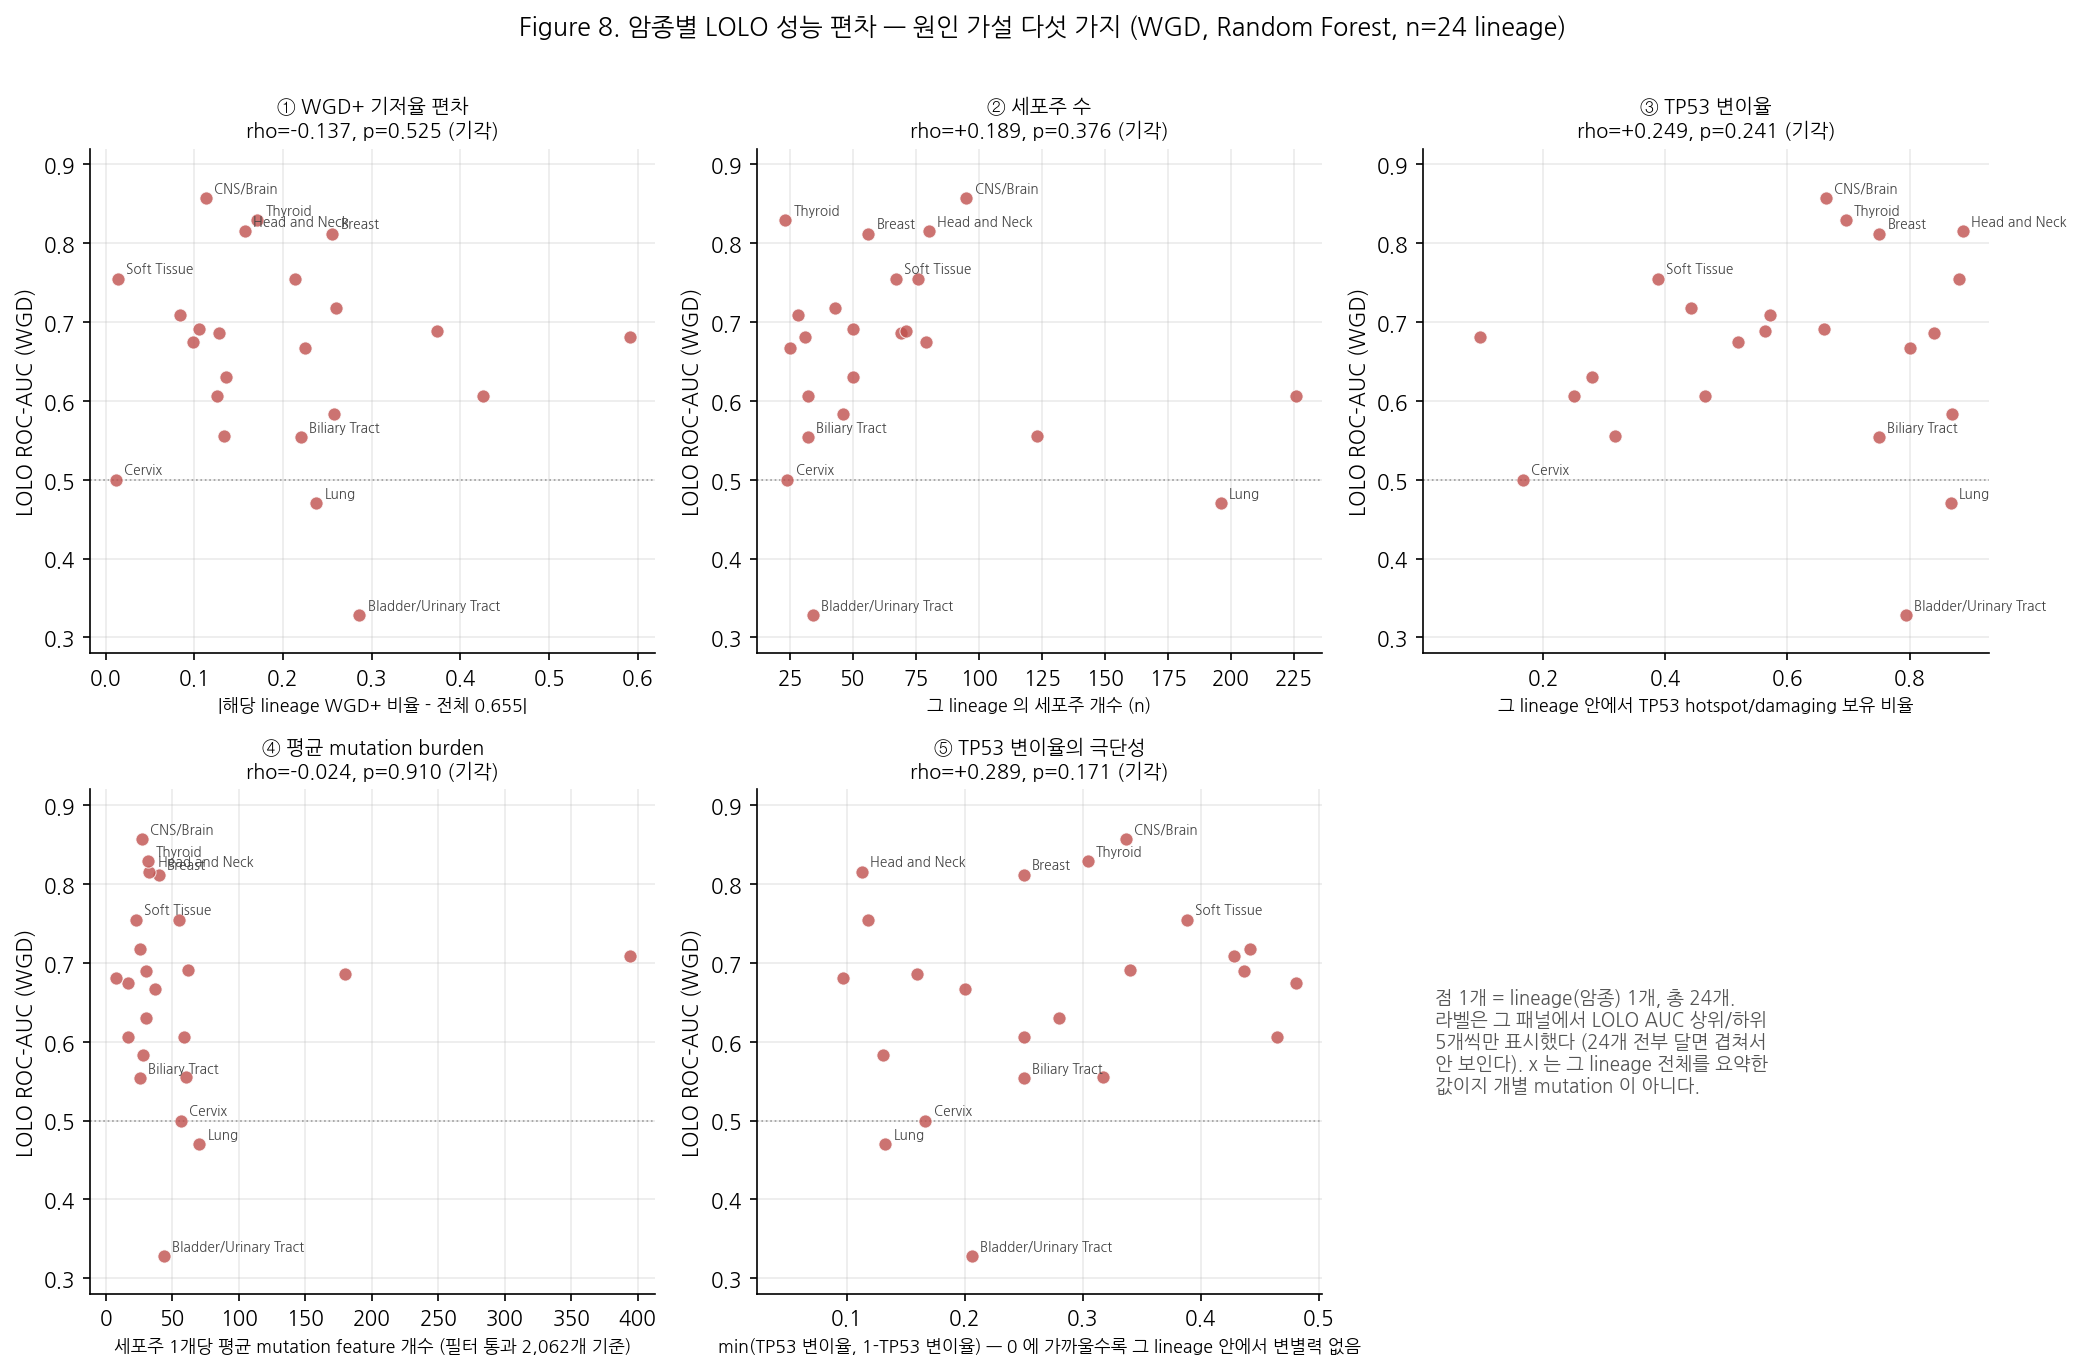

In [14]:
display(Image(filename=str(FIGURES / "fig8_lineage_hypotheses_random_forest_wgd.png")))

## 8. CIN/LOH 이진화가 정보를 버리는가 — 회귀로 직접 검증

CIN/LoHFraction을 중앙값으로 잘라 분류하는 대신, 같은 mutation feature로 연속값을
직접 회귀 예측해 분류 ROC-AUC와 비교한다.

재현: `python scripts/17_regression_vs_classification.py`.

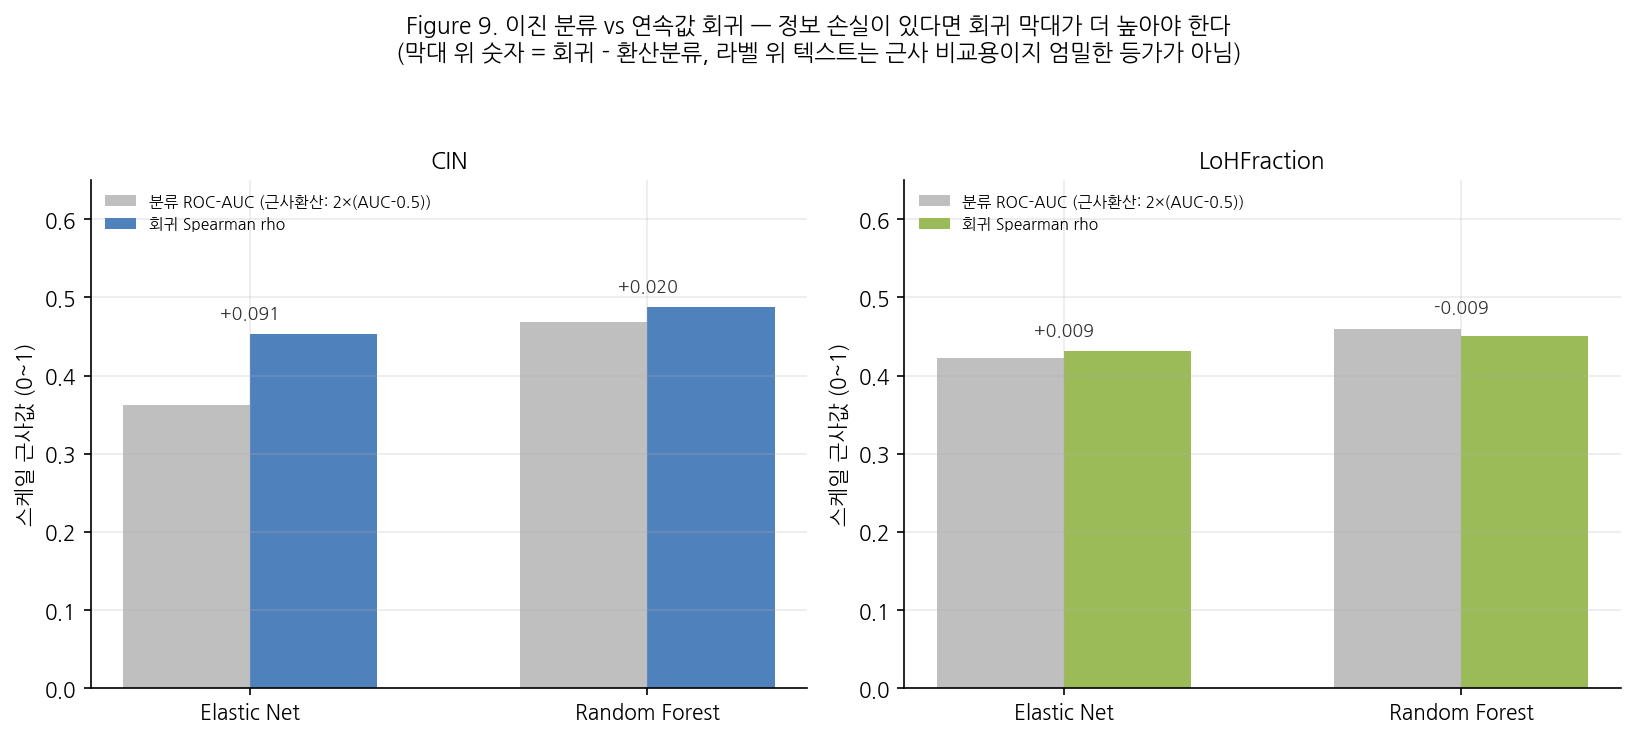

In [15]:
display(Image(filename=str(FIGURES / "fig9_regression_vs_classification.png")))

Random Forest는 CIN·LOH 어느 쪽도 이진화로 정보를 거의 잃지 않는다. **CIN을
Elastic Net(선형 모델)으로 볼 때만** 이진화가 신호를 깎아 먹는다(+0.091). 이
결과의 CIN 패널 재검증은 §11 참고.

## 9. Pathway 단위 재집계 — 실행 결과 (음성)

20,132개 유전자 컬럼을 MSigDB Hallmark 5개 + KEGG DNA repair 6개, 총 11개
gene set으로 재집계했을 때 성능이 어떻게 달라지는지 본다.

재현: `python scripts/19_pathway_representation.py`.

In [16]:
pathway = pd.read_csv(TABLES / "day19_pathway_vs_gene.csv")
pathway

,target,model,gene_level_auc,pathway_auc,차이
0,wgd,logistic,0.723,0.673775,-0.049225
1,cin,logistic,0.672,0.643151,-0.028849
2,loh,logistic,0.683,0.647836,-0.035164
3,wgd,random_forest,0.765,0.720302,-0.044698
4,cin,random_forest,0.734,0.691052,-0.042948
5,loh,random_forest,0.730,0.701923,-0.028077


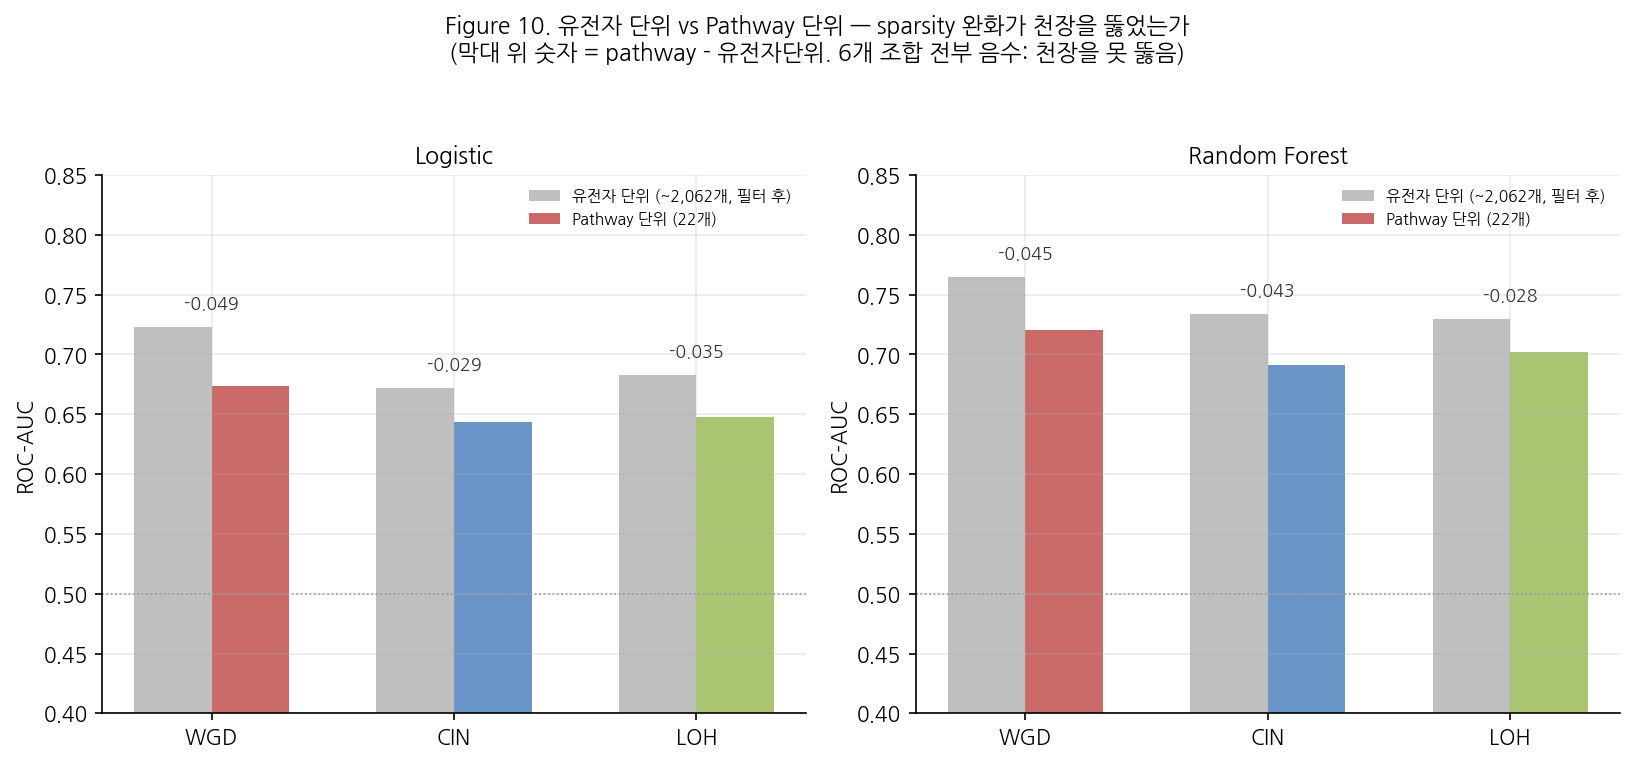

In [17]:
display(Image(filename=str(FIGURES / "fig10_pathway_vs_gene.png")))

**6개 조합(2모델×3표현형) 전부 pathway 쪽이 낮다(-0.028\~-0.049).** "sparsity를
줄이면 성능이 오른다"는 가설은 기각됐다 — 핵심 신호가 TP53 같은 소수 유전자에
집중돼 있어서, pathway로 뭉뚱그리면 오히려 정보가 희석된다.

## 10. Mutation Signature(96-class) 표현 — 실행 결과 (양성)

DepMap이 별도 배포하는 원시 MAF에서 trinucleotide context를 계산해, COSMIC SBS
표준 96-class 치환 비율을 세포주별 feature로 썼다 — pathway와 정반대로,
**유전자 정체성이 아니라 "어떤 변이 발생 과정이었는가"라는 다른 축의 정보**다.

재현: `python scripts/23_build_mutation_signature.py`,
`python scripts/24_signature_representation.py`.

In [18]:
sig = pd.read_csv(TABLES / "day24_signature_vs_gene.csv")
sig

,target,model,gene_level_auc,signature_auc,차이
0,wgd,logistic,0.723,0.713479,-0.009521
1,cin,logistic,0.672,0.710571,0.038571
2,loh,logistic,0.683,0.693428,0.010428
3,wgd,random_forest,0.765,0.770477,0.005477
4,cin,random_forest,0.734,0.761834,0.027834
5,loh,random_forest,0.730,0.742923,0.012923


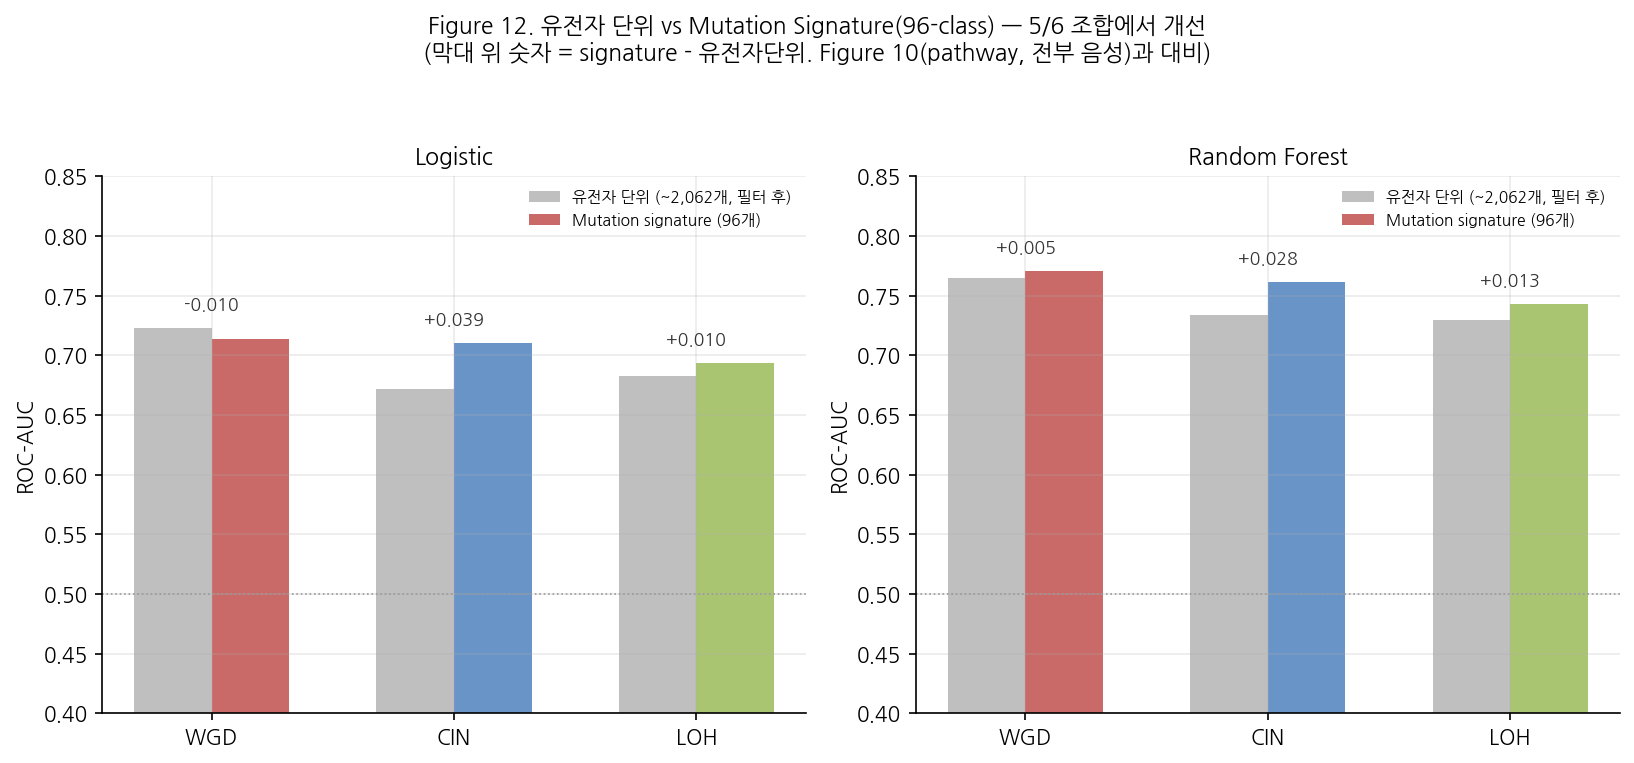

In [19]:
display(Image(filename=str(FIGURES / "fig12_signature_vs_gene.png")))

**6개 조합 중 5개가 개선됐다.** 96개라는 훨씬 적은 feature 수로 유전자
\~2,062개 수준의 성능을 냈다. Signature 자체의 최소 패널(20\~30개로 95\~99% 유지)과
3-seed 재현성(변동폭 0.001\~0.005, 매우 안정적) 검증 결과는 아래 Figure
13/15에 있다.

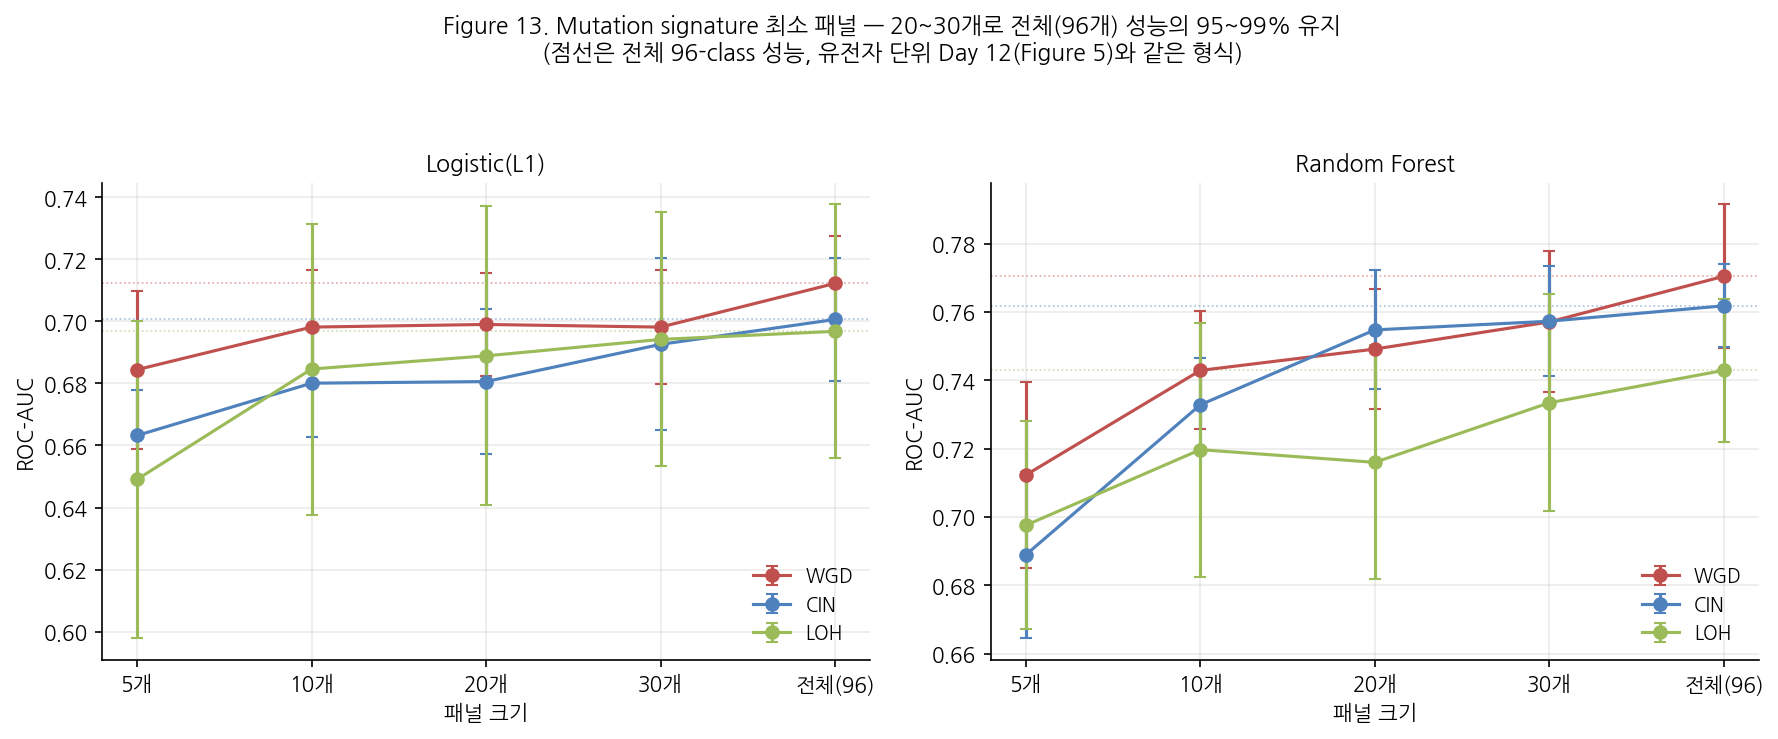

In [20]:
display(Image(filename=str(FIGURES / "fig13_signature_panel_curve.png")))

## 11. 유전자 + Signature 결합 패널

두 축(유전자 정체성 / 변이 발생 과정)을 한 feature 공간에 합쳐서 함께 feature
selection을 시키면 어떻게 될까?

재현: `python scripts/32_combined_gene_signature_panel.py`.

In [21]:
combined = pd.read_csv(TABLES / "day32_combined_vs_single_summary.csv")
combined.round(3)

,model,target,결합,유전자만,signature만,결합-유전자,결합-signature
0,logistic_l1,wgd,0.791,0.723,0.713,0.068,0.078
1,logistic_l1,cin,0.746,0.672,0.711,0.074,0.035
2,logistic_l1,loh,0.755,0.683,0.693,0.072,0.062
3,random_forest,wgd,0.797,0.765,0.770,0.032,0.027
4,random_forest,cin,0.775,0.734,0.762,0.041,0.013
5,random_forest,loh,0.765,0.730,0.743,0.035,0.022


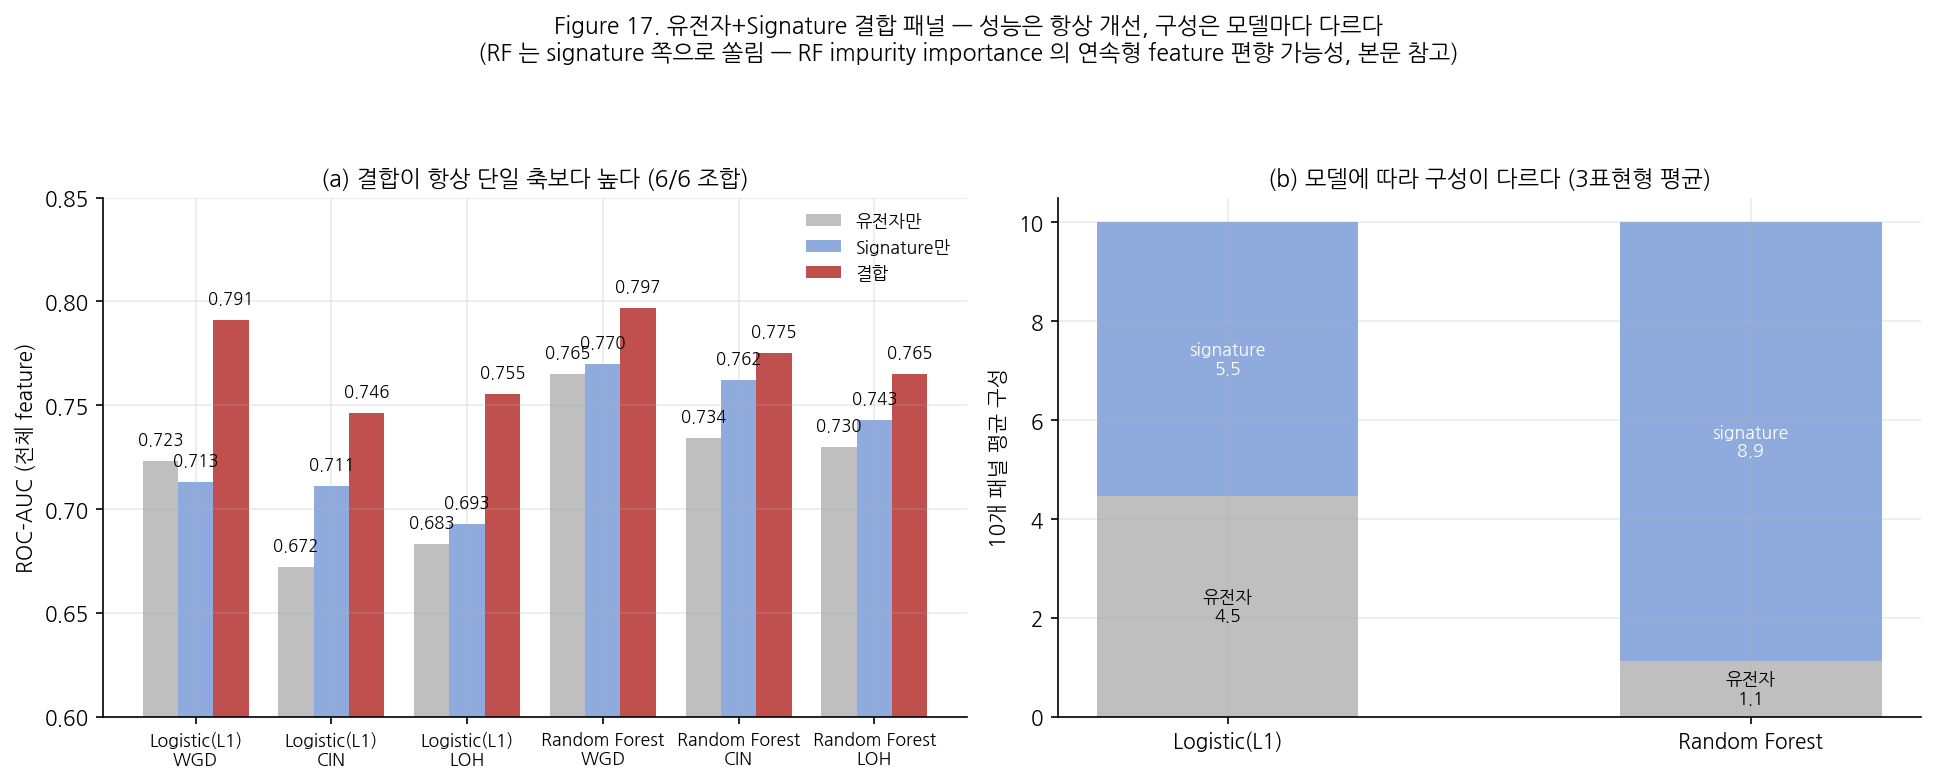

In [22]:
display(Image(filename=str(FIGURES / "fig17_combined_panel.png")))

**6개 조합 전부 결합이 단일 축(유전자만/signature만)보다 높다**
(+0.013\~+0.078). Random Forest+WGD(0.797)는 이 프로젝트 전체에서 가장 높은
ROC-AUC다. 다만 "결합 시 무엇이 선택되는가"는 모델에 따라 다르다 — Random
Forest는 Random Forest importance의 cardinality 편향으로 signature 쪽에 크게
쏠리고(TP53 한 개만 생존), Logistic(L1)은 균형 잡힌 구성을 보이며 기존 핵심
축(TP53/ID3/BRAF/CREBBP)이 그대로 유지된다.

### CIN 회귀 기반 패널 재검증

이진화 손실이 있었던 CIN/Elastic Net 조합에서, 분류 대신 회귀로 다시 뽑은
패널이 기존 분류 패널과 얼마나 겹치는지 확인한다.

재현: `python scripts/28_cin_regression_panel.py`.

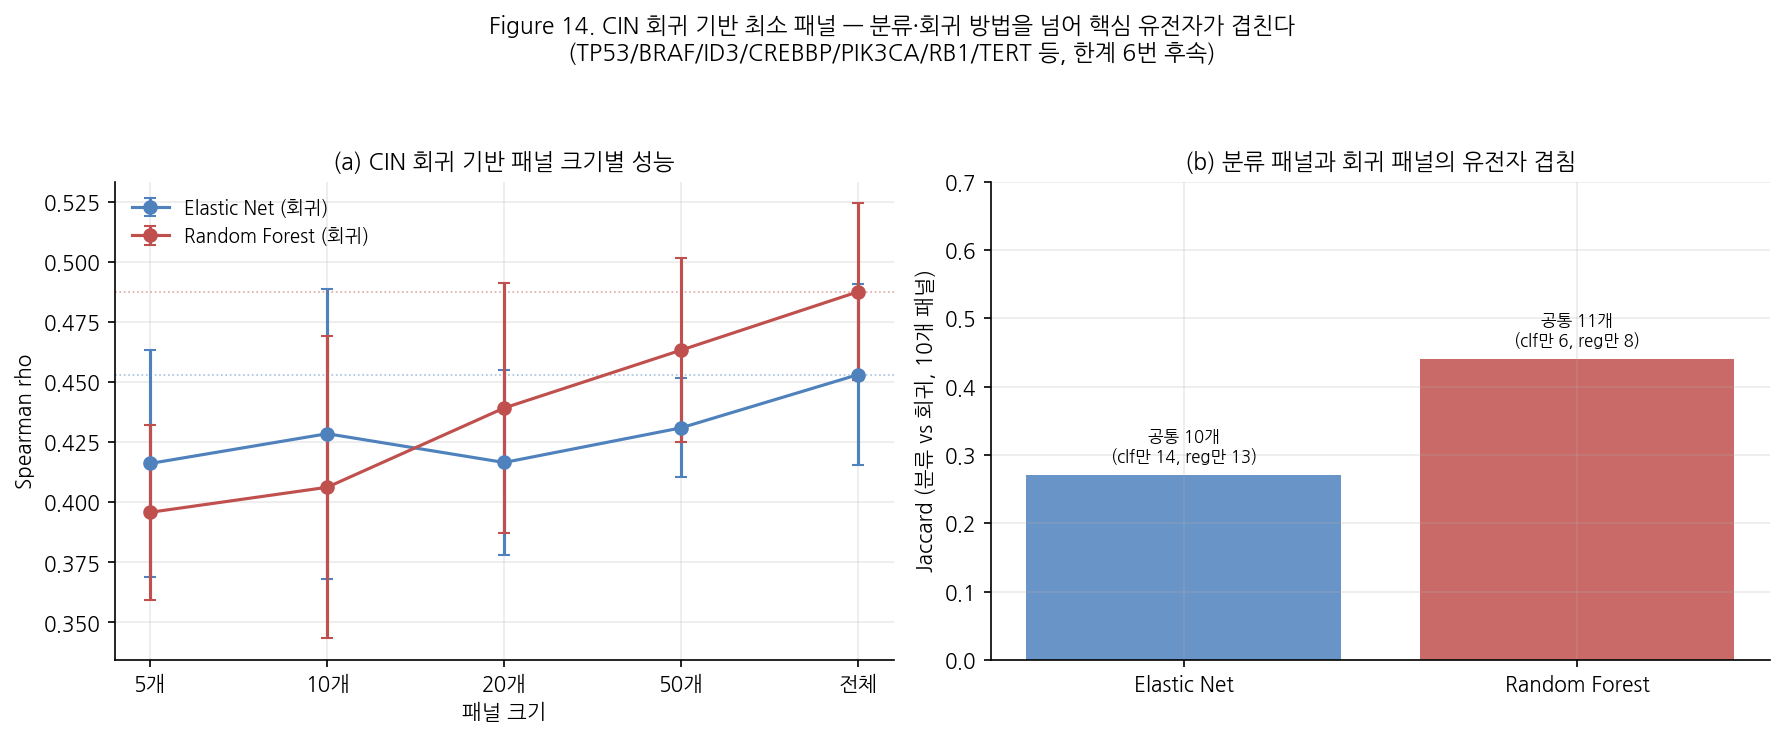

In [23]:
display(Image(filename=str(FIGURES / "fig14_cin_regression_panel.png")))

분류-회귀 두 방법을 넘어 TP53/BRAF/ID3/CREBBP/PIK3CA/RB1/TERT 핵심 축이 그대로
겹친다(Jaccard 0.27\~0.44) — 이진화 손실이 "어떤 유전자가 선택되는가"에는 크게
반영되지 않았다는 뜻이다.

## 12. Sensitivity/Specificity 트레이드오프

표현 방식(유전자 → signature → 결합)을 바꾸면 sensitivity/specificity 우세가
어떻게 이동하는지 본다.

재현: `python scripts/36_plot_sens_spec_tradeoff.py`.

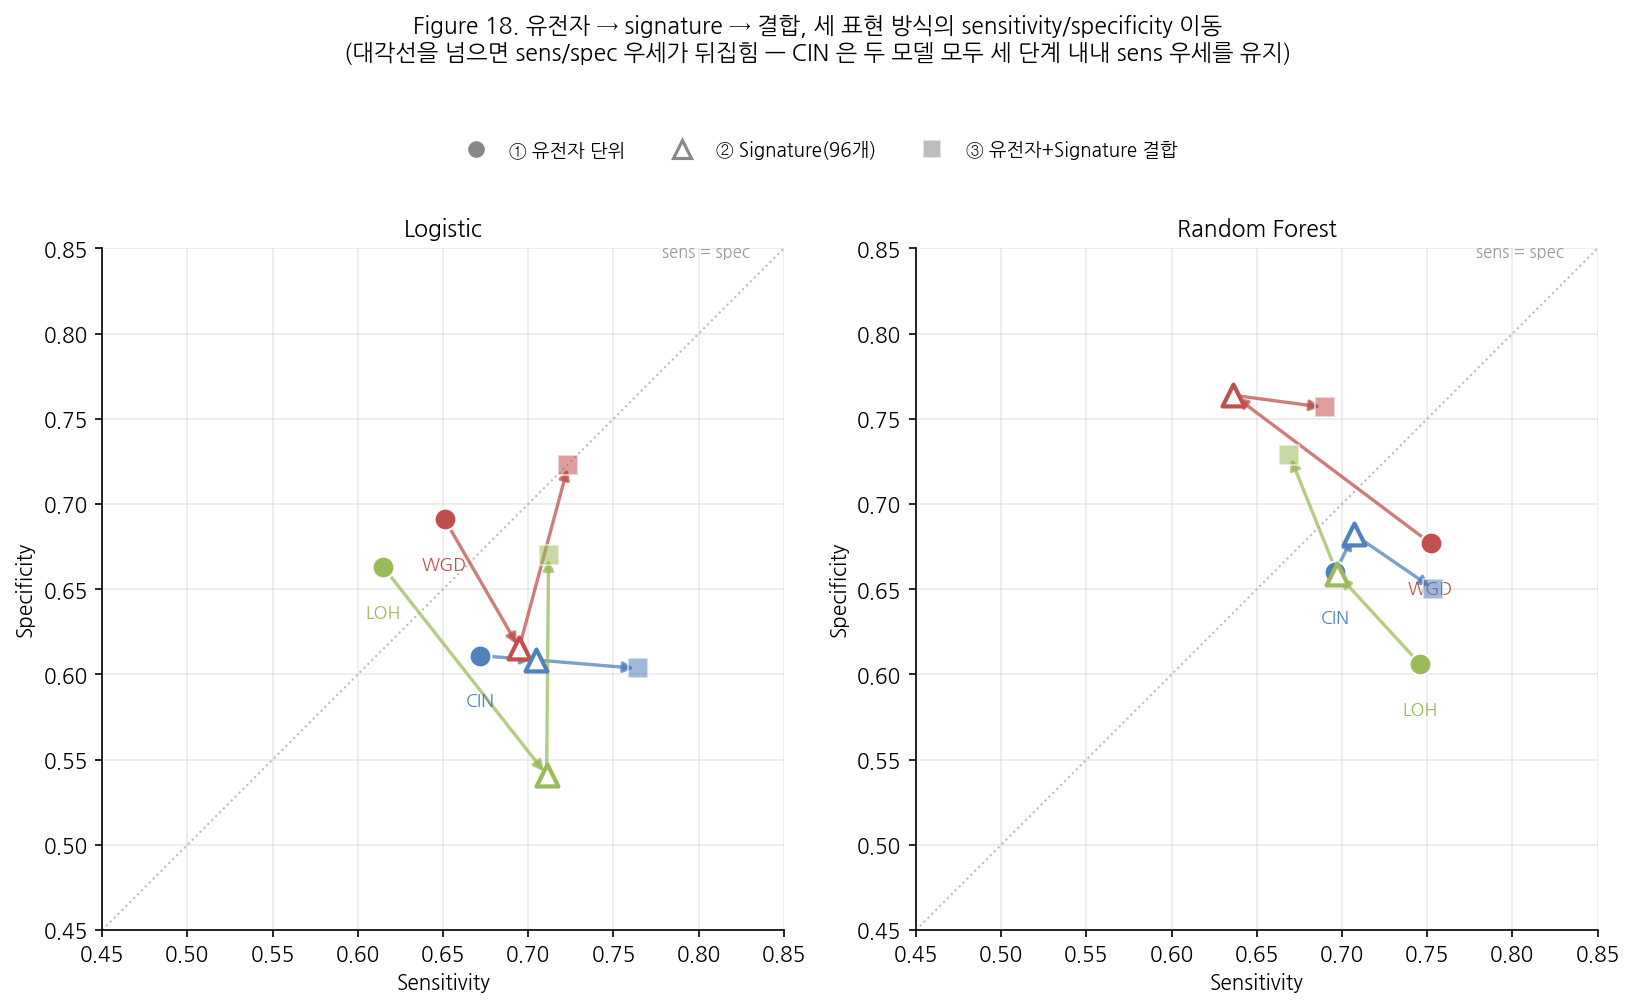

In [24]:
display(Image(filename=str(FIGURES / "fig18_sens_spec_tradeoff.png")))

CIN은 두 모델 모두 세 단계 내내 sensitivity 우세를 유지하는 반면, WGD와 LOH는
표현 방식을 바꿀 때 대각선(sens=spec)을 넘어가는 지점이 있다 — 표현형에 따라
"표현 방식 선택"이 예측 오류의 방향 자체를 바꿀 수 있다는 뜻이다.

## 13. TCGA 외부 코호트 검증

DepMap 세포주가 아니라 실제 환자 종양 조직(TCGA)에서 WGD를 외부 검증한다.
DepMap 전체로 학습한 모델을 그대로 TCGA에 적용했다(damaging feature만,
hotspot 대응 데이터 없음).

재현: `python scripts/21_tcga_validation.py`.

In [25]:
tcga = pd.read_csv(TABLES / "day21_tcga_validation_summary.csv")
tcga

,stage,roc_auc,n
0,"DepMap 내부(damaging-only, random 5-fold)",0.762229,1631
1,TCGA 외부 검증,0.594063,10261


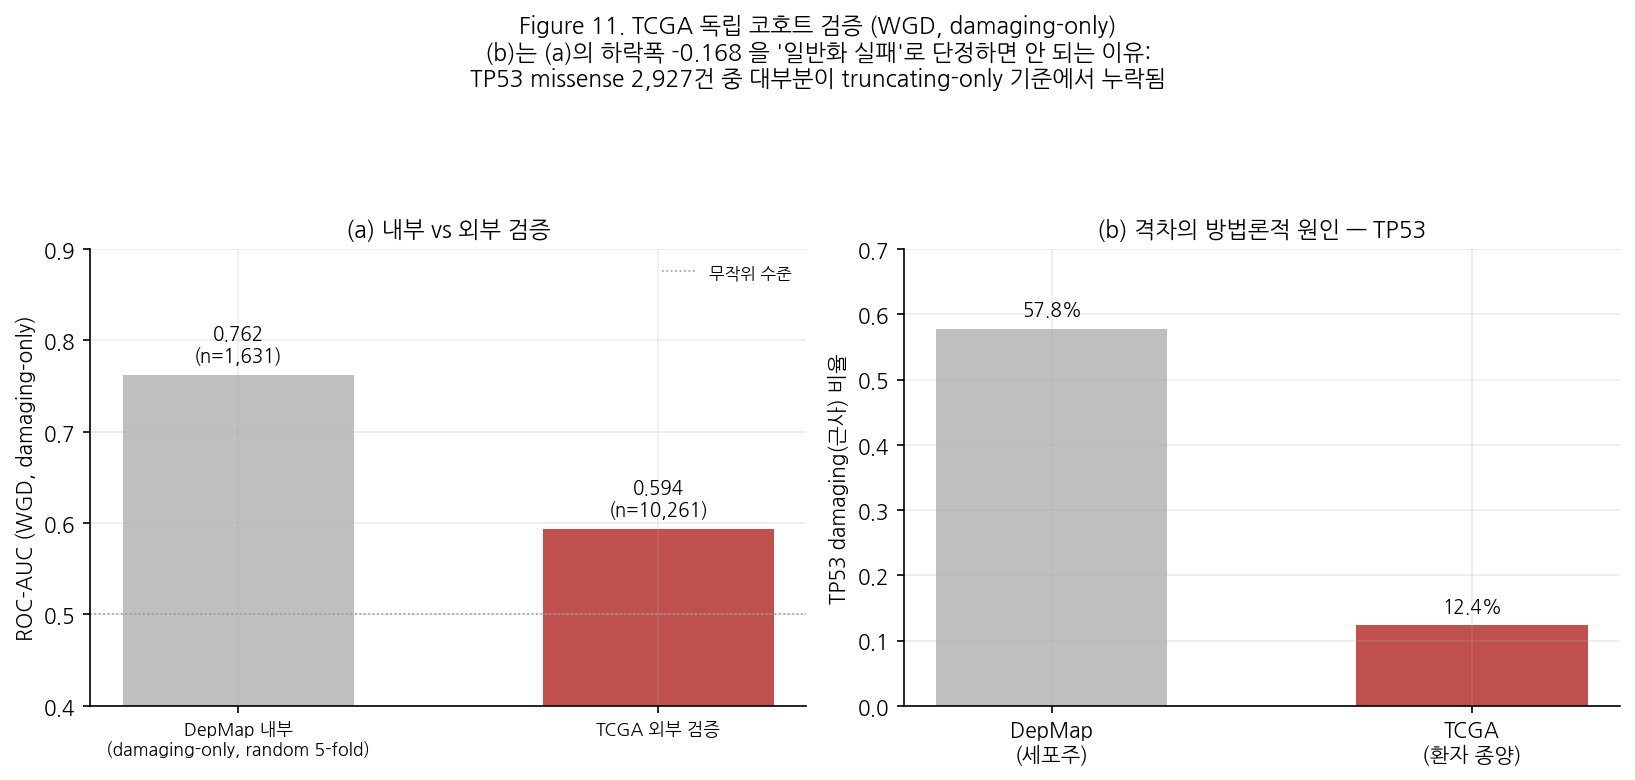

In [26]:
display(Image(filename=str(FIGURES / "fig11_tcga_validation.png")))

내부(0.762) 대비 외부(0.594)로 크게 떨어지지만, TCGA의 TP53 damaging 근사
비율이 DepMap보다 훨씬 낮다(57.8% vs 12.4%) — TP53의 주된 불활성화 경로인
missense 변이를 truncating-only 근사가 놓치기 때문으로, **0.594는 실제
일반화 성능의 하한 추정치**에 가깝다.

## 14. 최종 후보 Biomarker Panel

지금까지의 모든 근거(fold 반복선택, 모델 간 합의, 회귀 재검증, TCGA 방향성
지지)를 종합한 최종 후보 8개 유전자다. 상세 근거표는
`docs/research/2026-08-19/biomarker_panel.md` 참고.

In [27]:
core_genes = ["TP53 (damaging+hotspot)", "ID3", "BRAF (hotspot)", "CREBBP"]
phenotype_specific = {
    "WGD": "TERT (hotspot)",
    "CIN": "RB1, PIK3CA (hotspot)",
    "LOH": "PITX1",
}
print("핵심 축 (3표현형 공통):", ", ".join(core_genes))
print()
for target, genes in phenotype_specific.items():
    print(f"  {target} 특이: {genes}")

핵심 축 (3표현형 공통): TP53 (damaging+hotspot), ID3, BRAF (hotspot), CREBBP

  WGD 특이: TERT (hotspot)
  CIN 특이: RB1, PIK3CA (hotspot)
  LOH 특이: PITX1


## 15. 결론 및 한계

- DNA mutation만으로 WGD/CIN/LOH를 ROC-AUC 0.73\~0.77 수준까지 예측 가능하다
  (acceptable 구간이나, 유병률 대비 이득·확률 보정은 제한적).
- Random Forest가 최고 성능이며, 핵심 신호는 TP53을 중심으로 소수 유전자에
  집중돼 있다.
- lineage(암종)를 분리하면 성능이 크게 떨어지고, 그 편차의 원인은 규명하지
  못했다.
- Pathway 재집계는 음성, mutation signature 표현은 양성 — "유전자 정체성"과
  "변이 발생 과정"은 서로 다른, 상보적인 정보다.
- TCGA 외부 검증은 방향은 유지되나 방법론적 한계로 하한 추정치에 그친다.
- 이 결과는 **candidate minimal mutation biomarker panel**이지 임상 확정
  바이오마커가 아니다.

전체 서술형 문서:
- `docs/research/2026-08-16/final_conclusion.md` (Day 1\~13 핵심 결론)
- `docs/research/2026-08-19/additional_results.md` (후속 실험 상세)
- `docs/research/2026-08-19/biomarker_panel.md` (최종 후보 패널 근거)
- `docs/research/2026-08-19/model.md` (모델 비교 상세)